In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

%matplotlib inline

# Carrega a base principal já tratada para análise
csv_path = Path(r"C:\Users\mateu\OneDrive\Documentos\SPTECH\TCC\backend\tabela_final\part-00000-bc8041e1-56a7-4223-b839-8474dfbae85d-c000.csv")
df = pd.read_csv(csv_path, index_col=0, delimiter=",")

# Visualização inicial para validar estrutura e tipos
df.head()

,order_delivered_customer_date,holiday_at_shipping,approval_time_hours,handling_time_hours,shipping_delay_hours,delivery_time_days,purchase_hour,purchase_day_of_week,is_weekend,price,...,customer_meso_sao_jose_do_rio_preto,customer_meso_macro_metropolitana_paulista,customer_meso_bauru,customer_meso_araraquara,customer_meso_presidente_prudente,customer_meso_marilia,customer_meso_assis,customer_meso_aracatuba,customer_meso_itapetininga,customer_meso_litoral_sul_paulista
order_delivered_carrier_date,,,,,,,,,,,,,,,,,,,,,
2017-01-30T15:45:48.000Z,2017-02-02T12:07:30.000Z,0,13.500,60.241,-22.259,5.921,14,5,1,29.99,...,0,1,0,0,0,0,0,0,0,0
2017-01-30T15:45:48.000Z,2017-02-02T12:07:30.000Z,0,13.500,60.241,-22.259,5.921,14,5,1,29.99,...,0,1,0,0,0,0,0,0,0,0
2017-01-30T15:45:48.000Z,2017-02-02T12:07:30.000Z,0,13.500,60.241,-22.259,5.921,14,5,1,29.99,...,0,1,0,0,0,0,0,0,0,0
2017-01-30T15:45:48.000Z,2017-02-02T12:07:30.000Z,0,13.500,60.241,-22.259,5.921,14,5,1,29.99,...,0,1,0,0,0,0,0,0,0,0
2017-02-09T10:54:50.000Z,2017-02-15T15:41:51.000Z,0,73.354,55.075,32.430,11.551,2,6,1,239.00,...,0,1,0,0,0,0,0,0,0,0


In [2]:
# Seleciona apenas colunas numéricas (base do PCA)
df_numeric = df.select_dtypes(include=[np.number]).copy()

# Remove variáveis com potencial de leakage/target leakage
leakage_candidates = [
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "shipping_delay_hours",
    "delivery_time_days",
    "review_score",
]
df_numeric = df_numeric.drop(columns=leakage_candidates, errors='ignore')

# Remove linhas com ausentes para evitar distorções no escalonamento/PCA
df_numeric = df_numeric.dropna()

# Auto-escalando os dados (StandardScaler)
from sklearn.preprocessing import StandardScaler
scale_obj = StandardScaler()
df_scaled = pd.DataFrame(scale_obj.fit_transform(df_numeric), columns=df_numeric.columns)

print(f"Colunas usadas no PCA: {len(df_numeric.columns)}")
df_scaled.head()

Colunas usadas no PCA: 66


,holiday_at_shipping,approval_time_hours,handling_time_hours,purchase_hour,purchase_day_of_week,is_weekend,price,freight_value,product_weight_g,volume_cm3,...,customer_meso_sao_jose_do_rio_preto,customer_meso_macro_metropolitana_paulista,customer_meso_bauru,customer_meso_araraquara,customer_meso_presidente_prudente,customer_meso_marilia,customer_meso_assis,customer_meso_aracatuba,customer_meso_itapetininga,customer_meso_litoral_sul_paulista
0,-0.029295,0.180119,-0.062755,-0.132933,1.121113,1.762488,-0.504720,-1.749080,-0.524650,-0.675274,...,-0.174374,6.146902,-0.150391,-0.115995,-0.115733,-0.093484,-0.084185,-0.078666,-0.061152,-0.059172
1,-0.029295,0.180119,-0.062755,-0.132933,1.121113,1.762488,-0.504720,-1.749080,-0.524650,-0.675274,...,-0.174374,6.146902,-0.150391,-0.115995,-0.115733,-0.093484,-0.084185,-0.078666,-0.061152,-0.059172
2,-0.029295,0.180119,-0.062755,-0.132933,1.121113,1.762488,-0.504720,-1.749080,-0.524650,-0.675274,...,-0.174374,6.146902,-0.150391,-0.115995,-0.115733,-0.093484,-0.084185,-0.078666,-0.061152,-0.059172
3,-0.029295,0.180119,-0.062755,-0.132933,1.121113,1.762488,-0.504720,-1.749080,-0.524650,-0.675274,...,-0.174374,6.146902,-0.150391,-0.115995,-0.115733,-0.093484,-0.084185,-0.078666,-0.061152,-0.059172
4,-0.029295,3.173743,-0.128436,-2.385801,1.652522,1.762488,1.197198,0.060855,-0.413212,-0.595630,...,-0.174374,6.146902,-0.150391,-0.115995,-0.115733,-0.093484,-0.084185,-0.078666,-0.061152,-0.059172


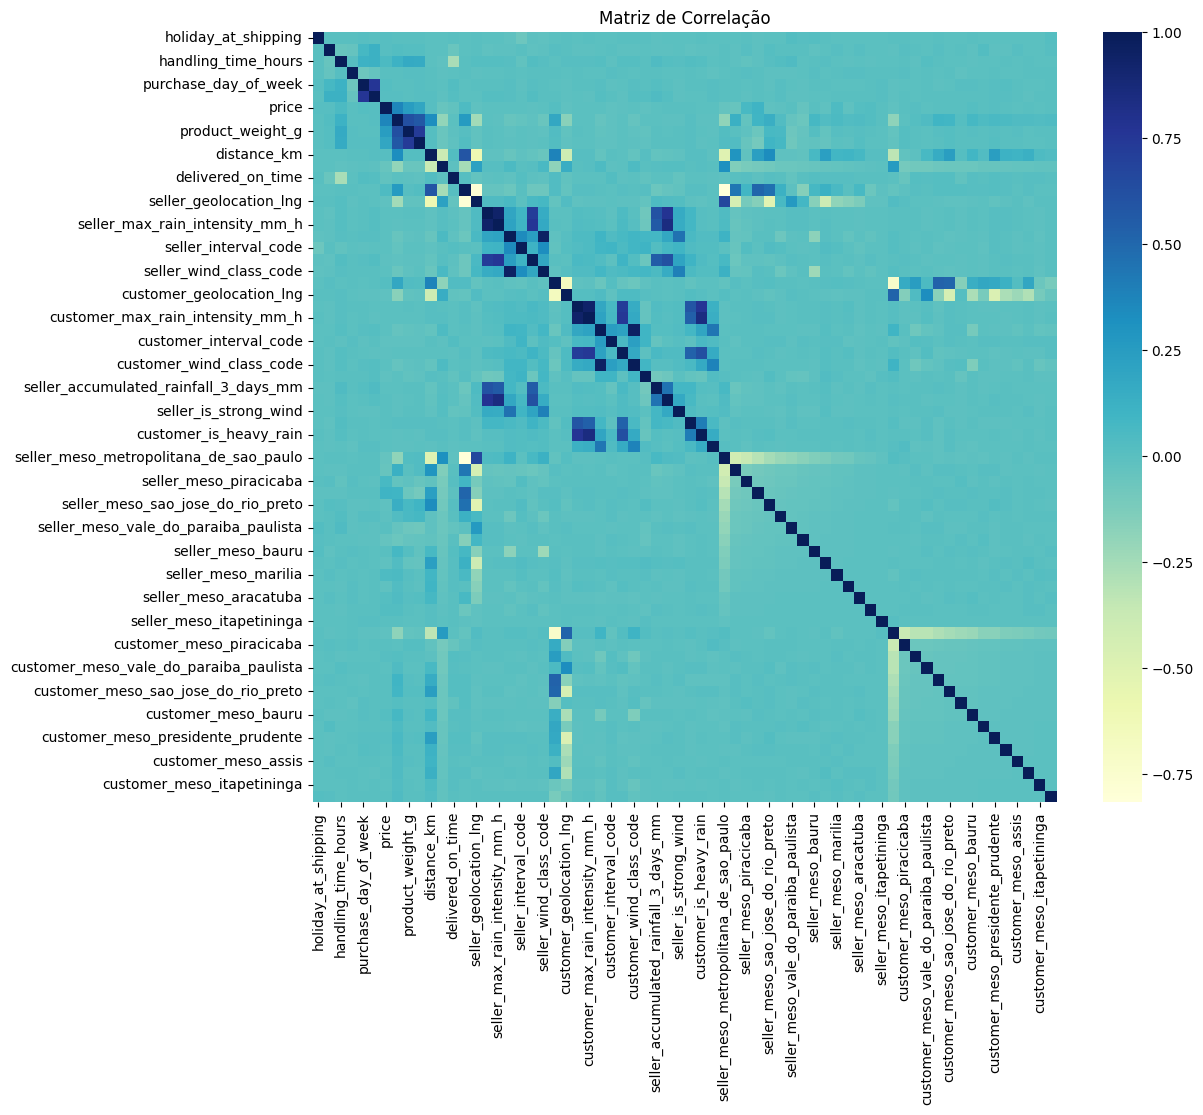

In [3]:
# Calculando a matriz de correlações
corr = df_scaled.corr()

# Heatmap da matriz de correlações
plt.figure(figsize=(12, 10))
sns.heatmap(corr, cmap="YlGnBu", annot=False)
plt.title("Matriz de Correlação")
plt.show()

In [4]:
from sklearn.decomposition import PCA

X = df_scaled.values
y = df["review_score"].values  

# Usa até 10 componentes, limitado ao número de variáveis disponíveis
n_components = min(10, X.shape[1])
pca = PCA(n_components=n_components)
pca.fit(X)

print("Variância explicada por cada componente:")
print(np.round(pca.explained_variance_ratio_, 3))

print("\nVariância acumulada:")
print(np.round(pca.explained_variance_ratio_.cumsum(), 3))

Variância explicada por cada componente:
[0.069 0.062 0.057 0.045 0.037 0.035 0.031 0.028 0.023 0.02 ]

Variância acumulada:
[0.069 0.131 0.187 0.233 0.27  0.305 0.336 0.363 0.386 0.406]


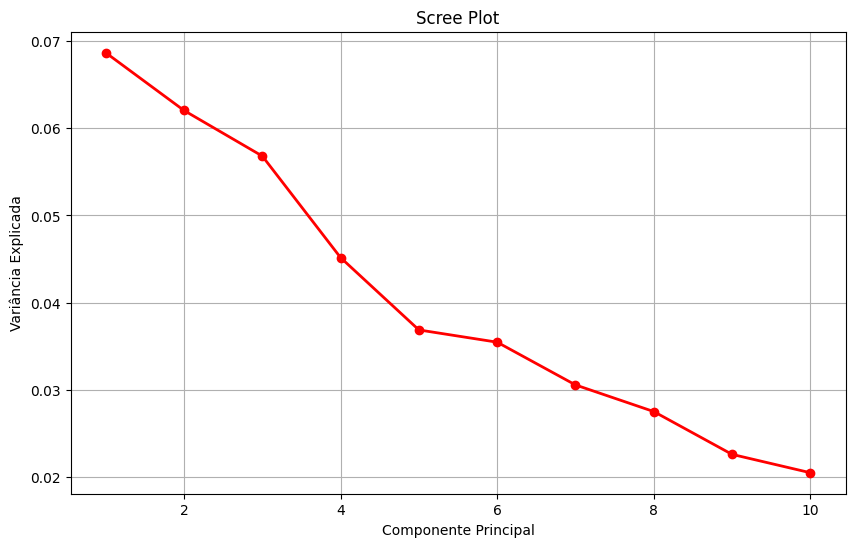

In [5]:
# Scree Plot
fig = plt.figure(figsize=(10, 6))

plt.plot(np.arange(1, len(pca.explained_variance_ratio_) + 1), pca.explained_variance_ratio_, 'ro-', linewidth=2)
plt.title('Scree Plot')
plt.xlabel("Componente Principal")
plt.ylabel('Variância Explicada')

plt.grid(True)
plt.show()

In [6]:
# Define o limiar mínimo de variância explicada acumulada
target_cumulative_variance = 0.80

# Ajusta um PCA completo para descobrir quantos componentes são necessários
pca_all = PCA()
pca_all.fit(X)
cumulative_variance = pca_all.explained_variance_ratio_.cumsum()

# Seleciona automaticamente o menor número de componentes que atinge o limiar
n_components_final = np.argmax(cumulative_variance >= target_cumulative_variance) + 1
pca_final = PCA(n_components=n_components_final)

# Calcula os scores uma única vez para evitar reprocessamento
scores = pca_final.fit_transform(X)

# Nomeia dinamicamente os componentes gerados
df_pca = df_numeric.copy()
for i in range(n_components_final):
    df_pca[f'PCA{i+1}'] = scores[:, i]

print(f"Componentes selecionados: {n_components_final}")
print(f"Variância acumulada atingida: {cumulative_variance[n_components_final - 1]:.3f}")

# Exibe os maiores scores no primeiro componente
df_pca.sort_values(by='PCA1', ascending=False).head(10)

Componentes selecionados: 35
Variância acumulada atingida: 0.808


,holiday_at_shipping,approval_time_hours,handling_time_hours,purchase_hour,purchase_day_of_week,is_weekend,price,freight_value,product_weight_g,volume_cm3,...,PCA26,PCA27,PCA28,PCA29,PCA30,PCA31,PCA32,PCA33,PCA34,PCA35
order_delivered_carrier_date,,,,,,,,,,,,,,,,,,,,,
2017-05-09T07:42:23.000Z,0,25.560,77.322,0,5,1,103.97,24.01,9750,37260.0,...,-2.690656,0.707002,-1.077079,-2.430371,0.560938,0.679369,0.049753,-0.273668,-0.424977,-0.306728
2017-04-26T07:26:16.000Z,0,0.162,34.517,20,1,0,184.90,28.48,6513,89984.0,...,-2.275187,0.509736,-0.970796,-1.797658,0.645911,0.460169,0.969517,0.201818,0.540833,0.021454
2018-05-18T10:48:00.000Z,0,6.951,11.241,16,4,0,85.00,27.45,1350,64000.0,...,2.517801,-1.952493,0.599741,0.702173,0.534794,-1.407442,-2.344696,-1.405959,-0.376628,-1.998683
2018-02-28T01:27:04.000Z,0,0.160,132.610,12,4,0,159.99,32.15,10700,64000.0,...,1.888485,-2.283911,0.521039,0.351375,0.821798,-1.352536,-1.466877,-0.826183,0.252965,-1.904762
2018-02-22T01:33:08.000Z,0,24.993,129.295,15,4,0,69.99,12.77,250,352.0,...,-7.354338,-7.998940,0.252626,8.134660,-6.540468,1.429061,-5.881345,4.719342,11.136836,3.735751
2017-02-11T07:55:50.000Z,0,0.194,34.011,21,4,0,178.00,22.16,11600,104000.0,...,-1.953121,1.095918,-1.351520,-1.097180,0.891454,-0.196091,0.177344,-0.871817,0.072376,-0.539088
2017-05-29T09:49:26.000Z,0,0.268,117.317,12,3,0,152.90,29.86,6513,89984.0,...,-0.526898,-0.015516,-0.391120,-0.472977,0.523056,0.143634,0.499455,0.607901,0.000241,0.586742
2017-05-09T09:46:10.000Z,0,0.223,24.402,9,1,0,32.90,11.85,400,1728.0,...,-7.549274,-8.002633,0.205704,8.084216,-6.632743,1.639775,-5.876577,4.635488,10.660889,3.715271
2018-07-04T06:49:00.000Z,0,141.143,-33.200,18,5,1,279.90,19.09,5200,27993.0,...,-7.091063,-8.053243,0.325064,8.770937,-7.195457,1.804632,-5.908826,4.740094,9.676877,2.831968


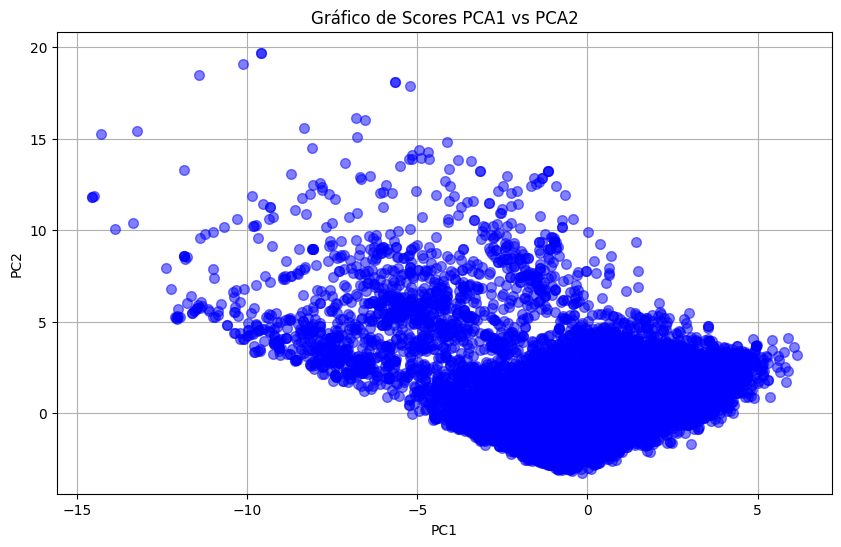

In [7]:
import matplotlib.pyplot as plt

# Gráfico de Scores (PCA1 x PCA2)
marker_style = dict(linestyle='none', marker='o', markersize=7, color='blue', alpha=0.5)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(scores[:, 0], scores[:, 1], label="Scores", **marker_style)

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_title("Gráfico de Scores PCA1 vs PCA2")
ax.grid(True)

plt.show()

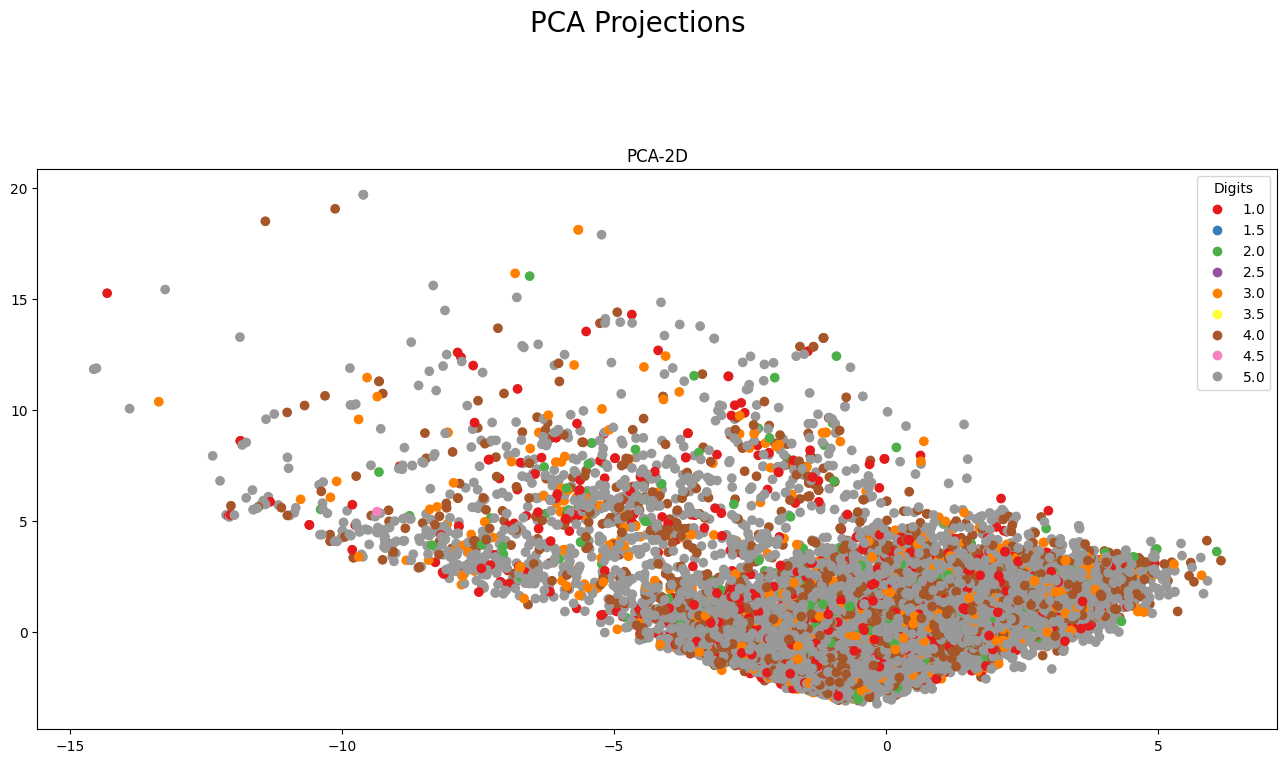

In [9]:
pca2d = PCA(n_components=2)
X_pca_2d = pca2d.fit_transform(X)


pca_3d = PCA(n_components=3)
X_pca_3d = pca_3d.fit_transform(X)

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import plotly.graph_objects as go
import plotly.colors

fig = plt.figure(figsize=(16, 16))
fig.suptitle('PCA Projections', fontsize=20)

# Plot the 2D projection
ax1 = fig.add_subplot(211)
ax1.title.set_text('PCA-2D')
scatter1 = ax1.scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], c=y, cmap='Set1')
legend1 = ax1.legend(*scatter1.legend_elements(), title='Digits')

# Create an interactive 3D plot using plotly
colorscale = plotly.colors.qualitative.Set1
fig3d = go.Figure(data=[go.Scatter3d(x=X_pca_3d[:, 0], y=X_pca_3d[:, 1], z=X_pca_3d[:, 2],
                                    mode='markers', marker=dict(color=y, colorscale=colorscale),
                                    text=y, hovertemplate='%{text}')])
fig3d.update_layout(title='PCA-3D', width=800, height=800)
fig3d.show()

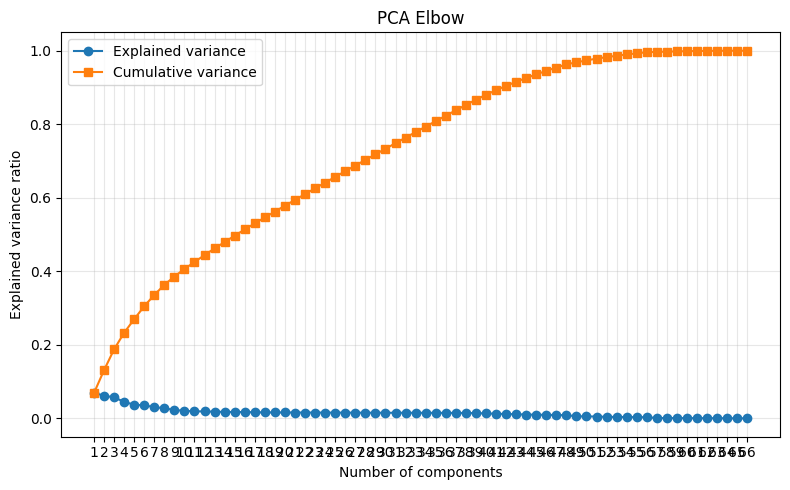

In [10]:
# PCA elbow: variance explained by each component
pca_elbow = PCA().fit(df_scaled)
explained = pca_elbow.explained_variance_ratio_
cumulative = np.cumsum(explained)

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(explained) + 1), explained, marker='o', label='Explained variance')
plt.plot(range(1, len(cumulative) + 1), cumulative, marker='s', label='Cumulative variance')
plt.xlabel('Number of components')
plt.ylabel('Explained variance ratio')
plt.title('PCA Elbow')
plt.xticks(range(1, len(explained) + 1))
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## Modelagem Matemática do PCA

O PCA (*Principal Component Analysis*) é uma técnica estatística utilizada para redução de dimensionalidade, transformando variáveis originais possivelmente correlacionadas em novas variáveis chamadas **Componentes Principais**.

### 1. Padronização dos Dados

Inicialmente, os dados são padronizados para que todas as variáveis fiquem na mesma escala, com média zero e desvio padrão igual a 1.

$$
z = \frac{x - \mu}{\sigma}
$$

Onde:

- $x$ = valor original  
- $\mu$ = média da variável  
- $\sigma$ = desvio padrão

---

### 2. Matriz de Covariância

Após a padronização, calcula-se a matriz de covariância, responsável por medir a relação entre as variáveis.

$$
Cov(X,Y)=\frac{\sum (x_i-\bar{x})(y_i-\bar{y})}{n-1}
$$

Essa etapa permite identificar quais variáveis variam juntas.

---

### 3. Cálculo dos Autovalores e Autovetores

Em seguida, o PCA resolve a equação:

$$
A\vec{v} = \lambda \vec{v}
$$

Onde:

- $A$ = matriz de covariância  
- $\lambda$ = autovalor  
- $\vec{v}$ = autovetor

Os **autovetores** indicam as direções dos novos eixos principais, enquanto os **autovalores** representam a quantidade de variância explicada por cada componente.

---

### 4. Formação dos Componentes Principais

Cada componente principal é formado por uma combinação linear das variáveis originais:

$$
PC_1 = a_1X_1 + a_2X_2 + ... + a_nX_n
$$

Onde:

- $X_1, X_2, ..., X_n$ = variáveis originais  
- $a_1, a_2, ..., a_n$ = pesos definidos pelos autovetores

---

### 5. Objetivo Final

O objetivo do PCA é reduzir o número de dimensões do conjunto de dados, preservando a maior quantidade possível de informação (variância), facilitando análises, visualizações e modelagens futuras.